In [1]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import xarray as xr
import math
import pickle

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

import statsmodels.api as sm
import pmdarima as pm


# Forcing Fitting RCIMP

In [2]:
with open("/glade/work/stevenxu/FAIR_models/origional_model.pkl", "rb") as f_in:
    f1 = pickle.load(f_in)

#with open("/glade/work/stevenxu/FAIR_models/top12_model.pkl", "rb") as f_in:
   # f2 = pickle.load(f_in)

#with open("/glade/work/stevenxu/FAIR_models/top20_model.pkl", "rb") as f_in:
    #f3 = pickle.load(f_in)

In [ ]:
for specie in f1.species:
    config = f1.configs[0]  # taking first config
    da = f1.forcing.sel(config=config, specie=specie)
    spread = da.max(dim="scenario") - da.min(dim="scenario")

    # Find the first year when spread is strictly greater than zero
    different_mask = spread > 0
    if different_mask.any():
        first_idx = int(np.argmax(different_mask.values))  # index of first True
        year_start_diff = int(spread["timebounds"].values[first_idx])
        print(specie, ': ' , year_start_diff)
    else:
        print(specie, ': ' , "never diverges")

## Finding the year when data diverges by scenarios
2017

In [23]:
for specie in f1.species:
    config = f1.configs[0]  # taking first config
    da = f1.forcing.sel(config=config, specie=specie)
    spread = da.max(dim="scenario") - da.min(dim="scenario")

    # Find the first year when spread is strictly greater than zero
    different_mask = spread > 0
    if different_mask.any():
        first_idx = int(np.argmax(different_mask.values))  # index of first True
        year_start_diff = int(spread["timebounds"].values[first_idx])
        print(specie, ': ' , year_start_diff)
    else:
        print(specie, ': ' , "never diverges")

CO2 FFI :  never diverges
CO2 AFOLU :  never diverges
CO2 :  2017
CH4 :  2017
N2O :  2017
Sulfur :  never diverges
BC :  never diverges
OC :  never diverges
NH3 :  never diverges
NOx :  never diverges
VOC :  never diverges
CO :  never diverges
CFC-11 :  never diverges
CFC-12 :  never diverges
CFC-113 :  2091
CFC-114 :  never diverges
CFC-115 :  never diverges
HCFC-22 :  never diverges
HCFC-141b :  never diverges
HCFC-142b :  never diverges
CCl4 :  never diverges
CHCl3 :  2017
CH2Cl2 :  2017
CH3Cl :  2017
CH3CCl3 :  never diverges
CH3Br :  2017
Halon-1211 :  never diverges
Halon-1301 :  never diverges
Halon-2402 :  never diverges
CF4 :  2017
C2F6 :  2017
C3F8 :  2017
c-C4F8 :  2017
C4F10 :  2017
C5F12 :  2017
C6F14 :  2017
C7F16 :  2017
C8F18 :  2017
NF3 :  2017
SF6 :  2017
SO2F2 :  2017
HFC-125 :  2017
HFC-134a :  2017
HFC-143a :  2017
HFC-152a :  2017
HFC-227ea :  2017
HFC-23 :  2017
HFC-236fa :  2017
HFC-245fa :  2017
HFC-32 :  2017
HFC-365mfc :  2017
HFC-4310mee :  2017
Solar :  nev

List of species that forcing is not existing

In [27]:
no_forcing_species = []
for specie in f1.species:
    da = f1.forcing.sel(scenario = f1.scenarios[0], specie=specie).mean(dim="config")
    if da.sum() == 0:
        no_forcing_species.append(specie)

no_forcing_species

['CO2 FFI',
 'CO2 AFOLU',
 'Sulfur',
 'BC',
 'OC',
 'NH3',
 'NOx',
 'VOC',
 'CO',
 'Equivalent effective stratospheric chlorine']

## Arima Fitting for each specie

In [ ]:
org_specie = f1.species
species_with_forcing = [s for s in org_specie if s not in no_forcing_species]
arima_list = {}
count = 0

for specie in species_with_forcing:
    count += 1
    print("Fitting ARIMA for ", specie, " ", count, "/", len(species_with_forcing))
    da = f1.forcing.sel(scenario = f1.scenarios[5], specie=specie, timebounds = slice(None, 2017)).mean(dim="config")
    model = pm.auto_arima(da.values, start_p=1, start_q=1,
                                max_p=3, max_q=3, m=12,
                                start_P=0, seasonal=True,
                                d=1, D=1, trace=True,
                                error_action='ignore',  # don't want to know if an order does not work
                                suppress_warnings=True,  # don't want convergence warnings
                                stepwise=True)  # set to stepwise
    arima_list[specie] = model

arima_list


In [ ]:
save_path = "/glade/work/stevenxu/FAIR_models/arima_list_forcing_RCIMP.pkl"
with open(save_path, "wb") as f:
    pickle.dump(arima_list, f)

# Emission Fitting RCIMP

In [22]:
for specie in f1.species:
    config = f1.configs[0]  # taking first config
    da = f1.emissions.sel(config=config, specie=specie)
    spread = da.max(dim="scenario") - da.min(dim="scenario")

    # Find the first year when spread is strictly greater than zero
    different_mask = spread > 0
    if different_mask.any():
        first_idx = int(np.argmax(different_mask.values))  # index of first True
        year_start_diff = int(spread["timepoints"].values[first_idx])
        print(specie, ': ' , year_start_diff)
    else:
        print(specie, ': ' , "never diverges")

CO2 FFI :  2016
CO2 AFOLU :  2016
CO2 :  2016
CH4 :  2015
N2O :  2016
Sulfur :  2016
BC :  2016
OC :  2015
NH3 :  2015
NOx :  2015
VOC :  2015
CO :  2015
CFC-11 :  never diverges
CFC-12 :  never diverges
CFC-113 :  2081
CFC-114 :  never diverges
CFC-115 :  never diverges
HCFC-22 :  never diverges
HCFC-141b :  never diverges
HCFC-142b :  never diverges
CCl4 :  never diverges
CHCl3 :  2016
CH2Cl2 :  2016
CH3Cl :  2016
CH3CCl3 :  never diverges
CH3Br :  2016
Halon-1211 :  never diverges
Halon-1301 :  never diverges
Halon-2402 :  never diverges
CF4 :  2016
C2F6 :  2016
C3F8 :  2016
c-C4F8 :  2016
C4F10 :  2016
C5F12 :  2016
C6F14 :  2016
C7F16 :  2016
C8F18 :  2016
NF3 :  2016
SF6 :  2016
SO2F2 :  2016
HFC-125 :  2016
HFC-134a :  2016
HFC-143a :  2016
HFC-152a :  2016
HFC-227ea :  2016
HFC-23 :  2016
HFC-236fa :  2016
HFC-245fa :  2016
HFC-32 :  2016
HFC-365mfc :  2016
HFC-4310mee :  2016
Solar :  never diverges
Volcanic :  never diverges
Aerosol-radiation interactions :  never diverges
Ae

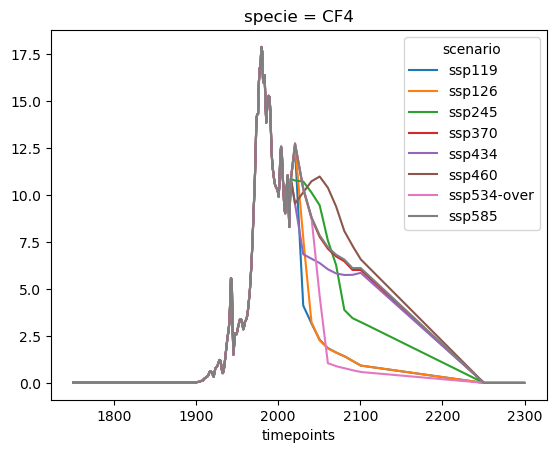

In [16]:
scenario = 'ssp585'
specie = 'CF4'
da = f1.emissions.sel(specie=specie).mean(dim="config")
da.plot.line(x="timepoints", hue="scenario")


## Finding the year when data diverges by scenarios
2015

In [28]:
for specie in f1.species:
    config = f1.configs[0]  # taking first config
    da = f1.emissions.sel(config=config, specie=specie)
    spread = da.max(dim="scenario") - da.min(dim="scenario")

    # Find the first year when spread is strictly greater than zero
    different_mask = spread > 0
    if different_mask.any():
        first_idx = int(np.argmax(different_mask.values))  # index of first True
        year_start_diff = int(spread["timepoints"].values[first_idx])
        print(specie, ': ' , year_start_diff)
    else:
        print(specie, ': ' , "never diverges")

CO2 FFI :  2016
CO2 AFOLU :  2016
CO2 :  2016
CH4 :  2015
N2O :  2016
Sulfur :  2016
BC :  2016
OC :  2015
NH3 :  2015
NOx :  2015
VOC :  2015
CO :  2015
CFC-11 :  never diverges
CFC-12 :  never diverges
CFC-113 :  2081
CFC-114 :  never diverges
CFC-115 :  never diverges
HCFC-22 :  never diverges
HCFC-141b :  never diverges
HCFC-142b :  never diverges
CCl4 :  never diverges
CHCl3 :  2016
CH2Cl2 :  2016
CH3Cl :  2016
CH3CCl3 :  never diverges
CH3Br :  2016
Halon-1211 :  never diverges
Halon-1301 :  never diverges
Halon-2402 :  never diverges
CF4 :  2016
C2F6 :  2016
C3F8 :  2016
c-C4F8 :  2016
C4F10 :  2016
C5F12 :  2016
C6F14 :  2016
C7F16 :  2016
C8F18 :  2016
NF3 :  2016
SF6 :  2016
SO2F2 :  2016
HFC-125 :  2016
HFC-134a :  2016
HFC-143a :  2016
HFC-152a :  2016
HFC-227ea :  2016
HFC-23 :  2016
HFC-236fa :  2016
HFC-245fa :  2016
HFC-32 :  2016
HFC-365mfc :  2016
HFC-4310mee :  2016
Solar :  never diverges
Volcanic :  never diverges
Aerosol-radiation interactions :  never diverges
Ae

List of species that forcing is not existing

In [26]:
no_emission_species = []
for specie in f1.species:
    da = f1.emissions.sel(scenario = f1.scenarios[0], specie=specie).mean(dim="config")
    if da.sum() == 0:
        no_emission_species.append(specie)

no_emission_species

['Solar',
 'Volcanic',
 'Aerosol-radiation interactions',
 'Aerosol-cloud interactions',
 'Ozone',
 'Light absorbing particles on snow and ice',
 'Stratospheric water vapour',
 'Land use',
 'Equivalent effective stratospheric chlorine']

## Arima Fitting for each specie

In [31]:
org_specie = f1.species
species_with_emissions = [s for s in org_specie if s not in no_emission_species]
arima_list = {}
count = 0

for specie in species_with_emissions:
    count += 1
    print("Fitting ARIMA for ", specie, " ", count, "/", len(species_with_emissions))
    da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2015)).mean(dim="config")
    model = pm.auto_arima(da.values, start_p=1, start_q=1,
                                max_p=3, max_q=3, m=12,
                                start_P=0, seasonal=True,
                                d=1, D=1, trace=True,
                                error_action='ignore',  # don't want to know if an order does not work
                                suppress_warnings=True,  # don't want convergence warnings
                                stepwise=True)  # set to stepwise
    arima_list[specie] = model

arima_list


Fitting ARIMA for  CO2 FFI   1 / 52
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=3.35 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=174.532, Time=0.19 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=90.653, Time=0.44 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=56.376, Time=1.12 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=148.815, Time=0.09 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=54.214, Time=0.84 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=87.896, Time=0.27 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=55.745, Time=1.34 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=52.996, Time=4.62 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=53.319, Time=1.53 sec
 ARIMA(0,1,1)(2,1,2)[12]             : AIC=inf, Time=5.45 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=inf, Time=3.44 sec
 ARIMA(1,1,1)(1,1,2)[12]             : AIC=34.857, Time=5.21 sec
 ARIMA(1,1,1)(0,1,2)[12]             : AIC=36.165, Time=4.44 sec
 ARIMA(1,1,1)(1,1,

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1898: RuntimeWarning: invalid value encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/pmdarima/arima/_auto_solvers.py:38: RuntimeWarning: invalid value encountered in divide
  max_invroot = max(0, *np.abs(1 / model.arroots()))
/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1905: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


 ARIMA(3,1,0)(1,1,2)[12]             : AIC=-1130.885, Time=0.84 sec
 ARIMA(3,1,0)(1,1,1)[12]             : AIC=-1157.764, Time=3.41 sec
 ARIMA(3,1,1)(0,1,2)[12]             : AIC=-1231.778, Time=6.29 sec
 ARIMA(3,1,1)(0,1,1)[12]             : AIC=inf, Time=4.05 sec
 ARIMA(3,1,1)(1,1,2)[12]             : AIC=-1221.015, Time=6.63 sec
 ARIMA(3,1,1)(1,1,1)[12]             : AIC=-1206.612, Time=6.57 sec
 ARIMA(2,1,1)(0,1,2)[12]             : AIC=-1209.209, Time=6.59 sec
 ARIMA(3,1,2)(0,1,2)[12]             : AIC=-1233.541, Time=8.71 sec
 ARIMA(3,1,2)(0,1,1)[12]             : AIC=-1230.112, Time=6.74 sec
 ARIMA(3,1,2)(1,1,2)[12]             : AIC=-1228.287, Time=6.96 sec
 ARIMA(3,1,2)(1,1,1)[12]             : AIC=-1189.401, Time=8.62 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=-1233.624, Time=9.99 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=inf, Time=5.30 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=-1232.095, Time=9.15 sec
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=6.86 se

{'CO2 FFI': ARIMA(order=(2, 1, 2), scoring_args={}, seasonal_order=(0, 1, 2, 12),
       suppress_warnings=True, with_intercept=False),
 'CO2 AFOLU': ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(2, 1, 2, 12),
       suppress_warnings=True, with_intercept=False),
 'CO2': ARIMA(order=(2, 1, 2), scoring_args={}, seasonal_order=(0, 1, 2, 12),
       suppress_warnings=True, with_intercept=False),
 'CH4': ARIMA(order=(1, 1, 3), scoring_args={}, seasonal_order=(1, 1, 1, 12),
       suppress_warnings=True),
 'N2O': ARIMA(order=(3, 1, 3), scoring_args={}, seasonal_order=(0, 1, 1, 12),
       suppress_warnings=True, with_intercept=False),
 'Sulfur': ARIMA(order=(1, 1, 2), scoring_args={}, seasonal_order=(2, 1, 0, 12),
       suppress_warnings=True, with_intercept=False),
 'BC': ARIMA(order=(2, 1, 3), scoring_args={}, seasonal_order=(0, 1, 1, 12),
       suppress_warnings=True, with_intercept=False),
 'OC': ARIMA(order=(2, 1, 1), scoring_args={}, seasonal_order=(1, 1, 1, 12),
       su

Saving list of model

In [32]:
save_path = "/glade/work/stevenxu/FAIR_models/arima_list_emission_RCIMP.pkl"
with open(save_path, "wb") as f:
    pickle.dump(arima_list, f)

## Special Species

## Turn off Seasonal Trend

In [3]:
with open("/glade/work/stevenxu/FAIR_models/arima_list_emission_RCIMP.pkl", "rb") as f:
    arima_list = pickle.load(f)

In [4]:
def forecast_plotting(specie, model, startyear=2015, endyear=2300):
	scenario_for_forecast = f1.scenarios[5]

	fig, ax = pl.subplots(figsize=(8,5))

	# historical
	da_hist = (
		f1.emissions
		.sel(specie=specie, scenario=scenario_for_forecast, timepoints=slice(None, 2015))
		.mean(dim="config")
	)
	ax.plot(da_hist["timepoints"].values, da_hist.values,
			linewidth=2.5, color="k", label=f"historical")

	#prediction
	n_steps = endyear - startyear
	ffl_fc, ffl_conf_int = model.predict(n_periods=n_steps, return_conf_int=True)
	future_years = np.arange(startyear + 1, endyear + 1)
	ax.plot(future_years, ffl_fc, linewidth=2, color="black", linestyle="--", label="ARIMA forecast")

	# CI interval
	ax.fill_between(future_years, ffl_conf_int[:,0], ffl_conf_int[:,1],
					alpha=0.2, label="95% CI")

	# plot scenarios
	for scen in f1.scenarios:
		da_all = (
			f1.emissions
			.sel(specie=specie, scenario=scen, timepoints=slice(startyear-1, endyear))
			.mean(dim="config")
		)
		ax.plot(da_all["timepoints"].values, da_all.values, label=str(scen))

	# views
	ax.axvline(startyear, color="k", linestyle=":", alpha=0.6)
	ax.set_xlabel("Year")
	ax.set_ylabel("Emission (Mt/yr)")
	ax.set_title(f"ARIMA Forecast of {specie} Emission")
	ax.legend(loc="best", ncol=1, frameon=True)
	pl.show()


### Sulfur

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1091.874, Time=0.67 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1119.338, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1093.649, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1096.347, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1128.864, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1088.643, Time=0.79 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1094.997, Time=0.23 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=1092.034, Time=0.51 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1083.579, Time=0.78 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1087.704, Time=0.59 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=1084.963, Time=1.31 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1090.835, Time=0.69 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1089.005, Time=0.60 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=1083.020, Time=2.21 sec
 ARIMA(3,1,3)(0,0,0)[0]          

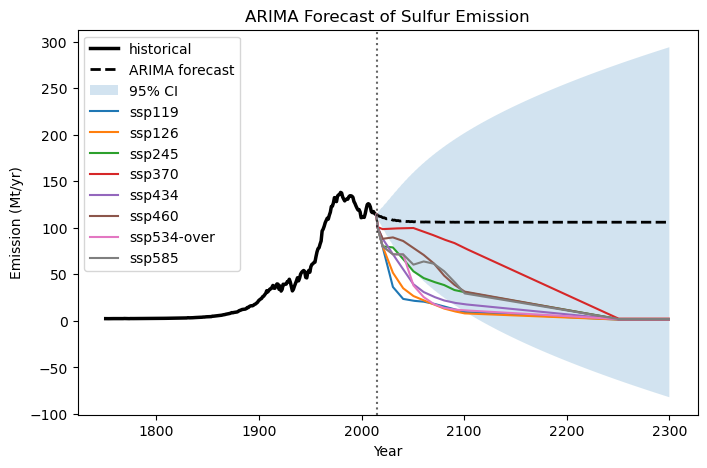

In [5]:
specie = "Sulfur"
da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2015)).mean(dim="config")
model = pm.auto_arima(da.values, start_p=1, start_q=1,
							max_p=3, max_q=3, 
							start_P=0,  seasonal=False,
							d=1, D=0, trace=True,
							error_action='ignore',  # don't want to know if an order does not work
							suppress_warnings=True,  # don't want convergence warnings
							stepwise=True)  # set to stepwise
#arima_list[specie] = model

model.summary()
forecast_plotting(specie, model, startyear=2015, endyear=2300)

### CFC-11

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1870.445, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2035.000, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1930.766, Time=0.16 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1868.463, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2033.089, Time=0.02 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1870.450, Time=0.46 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1867.042, Time=0.38 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1859.061, Time=0.79 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1864.643, Time=0.70 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=1838.297, Time=0.86 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=1847.047, Time=0.47 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=1807.794, Time=2.17 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1811.216, Time=2.09 sec
 ARIMA(3,1,3)(0,0,0)[0]             : AIC=1805.793, Time=1.96 sec
 ARIMA(2,1,3)(0,0,0)[0]          

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1420: RuntimeWarning: divide by zero encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum


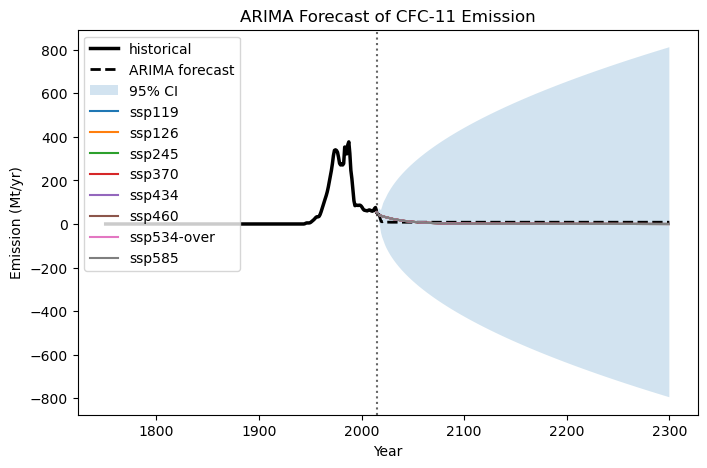

In [6]:
specie = "CFC-11"
da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2015)).mean(dim="config")
model = pm.auto_arima(da.values, start_p=1, start_q=1,
							max_p=3, max_q=3, 
							start_P=0,  seasonal=False,
							d=1, D=0, trace=True,
							error_action='ignore',  # don't want to know if an order does not work
							suppress_warnings=True,  # don't want convergence warnings
							stepwise=True)  # set to stepwise
#arima_list[specie] = model

model.summary()
forecast_plotting(specie, model, startyear=2015, endyear=2300)

### CFC-12

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-474.123, Time=0.48 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-297.793, Time=0.16 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-436.952, Time=0.28 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-447.247, Time=0.72 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-297.457, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-473.701, Time=0.69 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-475.788, Time=0.82 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-477.644, Time=0.60 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-475.761, Time=0.66 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-479.286, Time=1.69 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-477.097, Time=2.09 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-474.003, Time=1.51 sec
 ARIMA(1,1,3)(0,0,0)[0]             : AIC=-481.319, Time=0.44 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=-477.343, Time=0.16 sec
 ARIMA(1,1,2)(0,0,0)[0]          

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1420: RuntimeWarning: divide by zero encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum


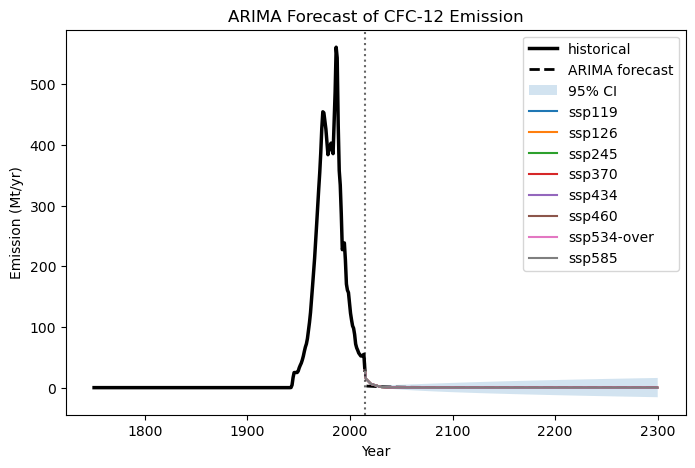

In [7]:
specie = "CFC-12"
da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2015)).mean(dim="config")
model = pm.auto_arima(np.log1p(da.values), start_p=1, start_q=1,
							max_p=3, max_q=3, 
							start_P=0,  seasonal=False,
							d=1, D=0, trace=True,
							error_action='ignore',  # don't want to know if an order does not work
							suppress_warnings=True,  # don't want convergence warnings
							stepwise=True)  # set to stepwise
#arima_list[specie] = model

model.summary()
forecast_plotting(specie, model, startyear=2015, endyear=2300)

## expm method

In [6]:
with open("/glade/work/stevenxu/FAIR_models/arima_list_emission_RCIMP.pkl", "rb") as f:
    arima_list = pickle.load(f)

In [19]:
def forecast_plotting(specie, model, startyear=2015, endyear=2300):
	scenario_for_forecast = f1.scenarios[5]

	fig, ax = pl.subplots(figsize=(8,5))

	# historical
	da_hist = (
		f1.emissions
		.sel(specie=specie, scenario=scenario_for_forecast, timepoints=slice(None, 2015))
		.mean(dim="config")
	)
	ax.plot(da_hist["timepoints"].values, da_hist.values,
			linewidth=2.5, color="k", label=f"historical")

	#prediction
	n_steps = endyear - startyear
	ffl_fc, ffl_conf_int = model.predict(n_periods=n_steps, return_conf_int=True)

	ffl_fc = np.expm1(ffl_fc)
	ffl_conf_int = np.expm1(ffl_conf_int)

	future_years = np.arange(startyear + 1, endyear + 1)
	ax.plot(future_years, ffl_fc, linewidth=2, color="black", linestyle="--", label="ARIMA forecast")

	# CI interval
	ax.fill_between(future_years, ffl_conf_int[:,0], ffl_conf_int[:,1],
					alpha=0.2, label="95% CI")

	# plot scenarios
	for scen in f1.scenarios:
		da_all = (
			f1.emissions
			.sel(specie=specie, scenario=scen, timepoints=slice(startyear-1, endyear))
			.mean(dim="config")
		)
		ax.plot(da_all["timepoints"].values, da_all.values, label=str(scen))

	# views
	ax.axvline(startyear, color="k", linestyle=":", alpha=0.6)
	ax.set_xlabel("Year")
	ax.set_ylabel("Emission (Mt/yr)")
	ax.set_title(f"ARIMA Forecast of {specie} Emission")
	ax.legend(loc="best", ncol=1, frameon=True)
	pl.show()


### CFC-11

In [9]:
specie = "CFC-11"
da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2015)).mean(dim="config")
model = pm.auto_arima(np.log1p(da.values), start_p=1, start_q=1,
							max_p=3, max_q=3, 
							start_P=0, m=12, 
                            seasonal=True,
							d=1, D=1, trace=True,
							error_action='ignore',  # don't want to know if an order does not work
							suppress_warnings=True,  # don't want convergence warnings
							stepwise=True)  # set to stepwise
#arima_list[specie] = model

model.summary()
#forecast_plotting(specie, model, startyear=2015, endyear=2300)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=3.33 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-320.929, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-521.469, Time=0.32 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=2.30 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-446.761, Time=0.07 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=-549.447, Time=1.09 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=3.39 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=1.46 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=-371.780, Time=0.53 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=-583.366, Time=0.92 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=-564.369, Time=0.60 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=inf, Time=3.66 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=3.54 sec
 ARIMA(3,1,0)(2,1,0)[12]             : AIC=-644.664, Time=2.39 sec
 ARIMA(3,1,0)(1,1,0)[12]             : AIC=-609.5

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1420: RuntimeWarning: divide by zero encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  265
Model:             SARIMAX(3, 1, 2)x(2, 1, [], 12)   Log Likelihood                 340.376
Date:                             Thu, 09 Oct 2025   AIC                           -664.751
Time:                                     20:49:22   BIC                           -636.516
Sample:                                          0   HQIC                          -653.390
                                             - 265                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2756      0.089     14.256      0.000       1.100       1.451
ar.L2         -0.8037      0.087     -9.287      0.000      -0.973      -0.634
ar.L3          0.4306      0.044      9.841      0.000       0.345       0.516
ma.L1          0.0619      0.093      0.669      0.503      -0.119       0.243
ma.L2         -0.4506      0.075     -6.022      0.000      -0.597      -0.304
ar.S.L12      -0.7689      0.029    -26.363      0.000      -0.826      -0.712
ar.S.L24      -0.4357      0.025    -17.168      0.000      -0.485      -0.386
sigma2         0.0037   8.07e-05     45.485      0.000       0.004       0.004
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             10177.72
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):                inf   Skew:                             1.63
Prob(H) (two-sided):                  0.00   Kurtosis:                        33.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

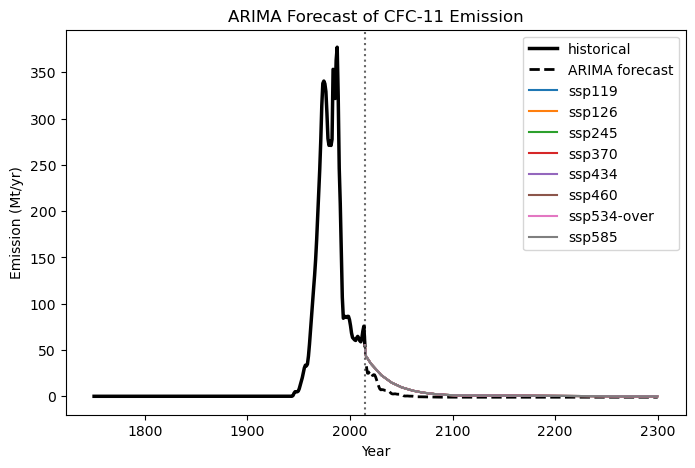

In [12]:
forecast_plotting(specie, model, startyear=2015, endyear=2300)

### Sulfur

In [14]:
specie = "Sulfur"
da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2015)).mean(dim="config")
model = pm.auto_arima(np.log1p(da.values), start_p=1, start_q=1,
							max_p=3, max_q=3, 
							start_P=0, m=12, 
                            seasonal=True,
							d=1, D=1, trace=True,
							error_action='ignore',  # don't want to know if an order does not work
							suppress_warnings=True,  # don't want convergence warnings
							stepwise=True)  # set to stepwise
#arima_list[specie] = model

model.summary()
#forecast_plotting(specie, model, startyear=2015, endyear=2300)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=1.94 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-773.580, Time=0.14 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-857.502, Time=0.49 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.74 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-776.975, Time=0.15 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=-872.992, Time=1.36 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=2.74 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=2.20 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=-872.752, Time=0.43 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=-871.044, Time=1.17 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=-871.027, Time=1.30 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=-872.922, Time=0.88 sec
 ARIMA(2,1,1)(2,1,0)[12]             : AIC=-876.061, Time=2.47 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=-863.394, Time=2.11 sec
 ARIMA(2,1,1)(2,1,1)[12]             : 

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  265
Model:             SARIMAX(2, 1, 2)x(2, 1, [1], 12)   Log Likelihood                 459.336
Date:                              Thu, 09 Oct 2025   AIC                           -902.673
Time:                                      20:53:54   BIC                           -874.437
Sample:                                           0   HQIC                          -891.311
                                              - 265                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6676      0.041    -16.249      0.000      -0.748      -0.587
ar.L2         -0.9006      0.032    -28.172      0.000      -0.963      -0.838
ma.L1          0.7620      0.030     25.667      0.000       0.704       0.820
ma.L2          0.9473      0.029     32.401      0.000       0.890       1.005
ar.S.L12       0.0426      0.068      0.629      0.529      -0.090       0.175
ar.S.L24       0.0752      0.076      0.989      0.322      -0.074       0.224
ma.S.L12      -0.8690      0.069    -12.590      0.000      -1.004      -0.734
sigma2         0.0014   9.09e-05     15.604      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):               304.03
Prob(Q):                              0.72   Prob(JB):                         0.00
Heteroskedasticity (H):               8.57   Skew:                            -0.98
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

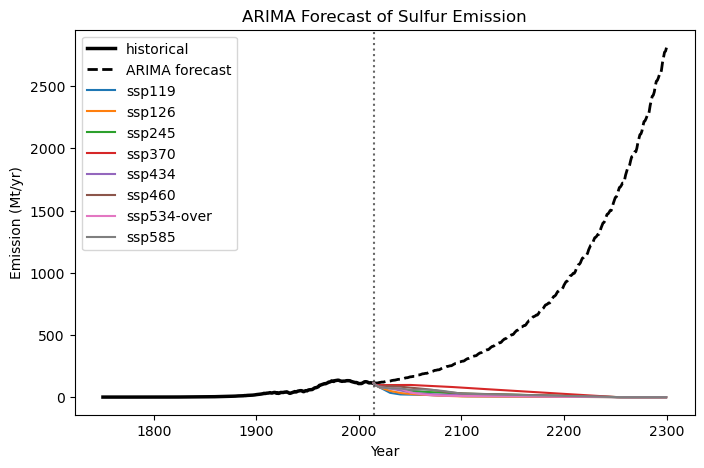

In [17]:
forecast_plotting(specie, model, startyear=2015, endyear=2300)

### CFC-12

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=1.88 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-150.113, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-317.544, Time=0.34 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.69 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-263.505, Time=0.18 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=-340.903, Time=0.76 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=3.30 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=1.64 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=-211.859, Time=0.39 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=-372.894, Time=0.91 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=-355.060, Time=0.34 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=inf, Time=3.87 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=1.68 sec
 ARIMA(3,1,0)(2,1,0)[12]             : AIC=-381.382, Time=1.01 sec
 ARIMA(3,1,0)(1,1,0)[12]             : AIC=-361.5

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1420: RuntimeWarning: divide by zero encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum


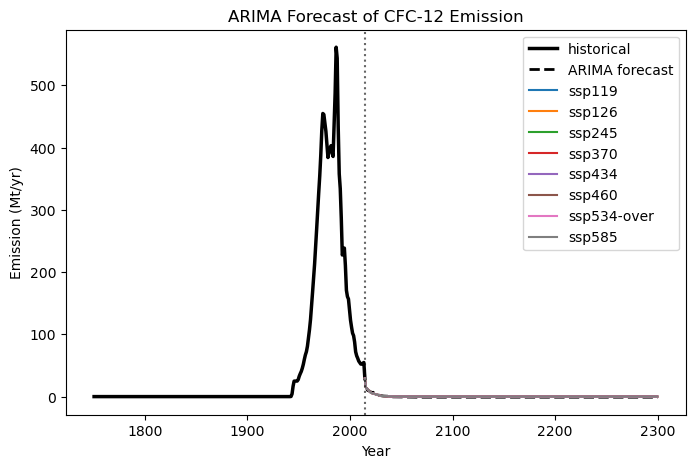

In [18]:
specie = "CFC-12"
da = f1.emissions.sel(scenario = f1.scenarios[5], specie=specie, timepoints = slice(None, 2015)).mean(dim="config")
model = pm.auto_arima(np.log1p(da.values), start_p=1, start_q=1,
							max_p=3, max_q=3, 
							start_P=0, m=12, 
                            seasonal=True,
							d=1, D=1, trace=True,
							error_action='ignore',  # don't want to know if an order does not work
							suppress_warnings=True,  # don't want convergence warnings
							stepwise=True)  # set to stepwise
#arima_list[specie] = model

model.summary()
forecast_plotting(specie, model, startyear=2015, endyear=2300)

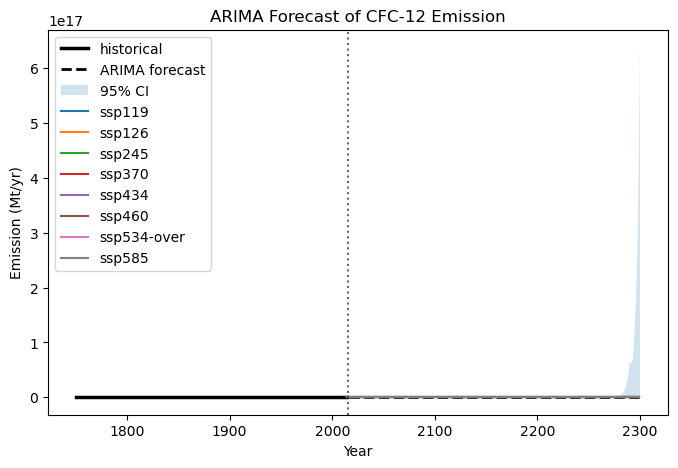

In [20]:
forecast_plotting(specie, model, startyear=2015, endyear=2300)